### Stochastic interpolant with **equivariant OT**: COM-free Gaussian → LJ13 cluster

Instead of training from scratch, we warm-start
the drift from the released **`LJ13_eq_OT_flow_matching`** checkpoint (Klein, Kraemer & Noé
2023; OSF [srqg7](https://osf.io/srqg7/)) and learn a score field alongside it, turning a
plain flow into a proper stochastic interpolant.
What we need in this notebook:

- `load_ref_data`  — the target dataset `p₁`: OSF MCMC samples of the 13-atom LJ cluster.
- `sample_prior`   — the base `p₀`: COM-free unit Gaussian on the 36-dim mean-zero subspace.
- `make_si_model`  — an `LJ13EESI` wrapping two `LJ13Dynamics` E(n)-GNNs (drift + score).
- `train` — Training with equivariant OT coupling
  (`eesi.systems.lj13.ot.equivariant_ot_couple`) which runs under `no_grad` and just re-pairs the batch before
  `model.loss`, so nothing about the interpolant changes.

The coupling has two independent layers, toggled per call: `align` (OT over the symmetry
group S(13) × SO(3)) and `batch` (minibatch OT over the batch). For LJ13 the group is large
and `align` dominates — the opposite of the XY chain, where the group is tiny.


### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi.systems.lj13.data import load_ref_data, sample_prior, lj_energy
from eesi.systems.lj13.dynamics import LJ13Dynamics, rk4_sample, integrate_with_logdet
from eesi.systems.lj13.ot import equivariant_ot_couple
from eesi.ot import transport_cost
from eesi.systems.lj13.train import make_si_model, train_si

%matplotlib inline
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [2]:
_IU = torch.triu_indices(55, 55, offset=1)          # the 78 unique pairs

def pair_distances(x):                              # (B,13,3) -> (B*78,) all pair distances
    iu = _IU.to(x.device)
    d = x[:, iu[0]] - x[:, iu[1]]
    return d.pow(2).sum(-1).sqrt().reshape(-1).cpu().numpy()

def energy(x):                                      # physical (i<j) LJ energy, min = -44.327
    return lj_energy(x, ordered=False).cpu().numpy()

def smooth(v, k=25):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

# Apply a sampler to x0 in chunks. The ODE/SDE have no batch coupling, so this is
# exactly equivalent to one big call -- it only caps peak GPU memory (13 atoms x
# 156 directed edges per config adds up fast at B=5000).
@torch.no_grad()
def chunked(fn, x0, size=1000):
    return torch.cat([fn(c) for c in x0.split(size)])

### 1. Datasets & samplers

`load_ref_data` slices the memory-mapped 10M × 39 OSF array *before* materializing it, so we
never pull the full 1.5 GB into RAM. The shipped configurations are already COM-free;
re-centering only removes float drift. `sample_prior` is the base `p₀`, drawn fresh each
step. Both distributions are S(13) × SO(3)-invariant, which is what makes the
equivariant-OT coupling marginal-preserving.

In [3]:
# only grabbing a small sub-sample
n_data = 100_000
x1 = load_ref_data(n=n_data).to(device)
print("target dataset:", tuple(x1.shape))


e_ref = energy(x1)
print(f"reference energy: <E> = {e_ref.mean():+.3f}   min = {e_ref.min():+.3f} ")

target dataset: (100000, 55, 3)
reference energy: <E> = -203.848   min = -224.235 


### 2. Model & checkpoint load

`make_si_model` returns an `LJ13EESI` wrapping two independent `LJ13Dynamics` E(n)-GNNs, one
for the drift `b` and one for the score `s`. We use the **linear** path, matching the
convention the released checkpoint was trained under, with a `sqrt` latent-noise schedule so
the score trains against the cheap antithetic denoising objective rather than implicit score
matching.

The checkpoint is a *flow-matching velocity*, i.e. exactly `b(t,x) = E[x₁ − x₀ | x_t]` for
the **noiseless** linear interpolant. Switching on the latent noise (`gamma_scale > 0`)
smears the marginals slightly, so the checkpoint is a close **warm start** for `net_b`, not
the exact optimum — it lands the drift in the right basin and training refines it from
there. `net_s` starts from scratch.

In [8]:
torch.manual_seed(1)

batch_size=64

model = make_si_model(
    n_particles=55, n_dims=3,
    path="linear", gamma="sqrt", gamma_scale=0.2,
    score_div_method="exact",learn_score=False,
    hidden_nf = 64, n_layers = 4,
).to(device=device, dtype=torch.float64)

print("net_b params:", sum(p.numel() for p in model.net_b.parameters()))
print("net_s params:", sum(p.numel() for p in model.net_s.parameters()))

# Warm-start the drift from the released OSF equivariant-OT flow-matching checkpoint.
ckpt = LJ13Dynamics.from_checkpoint().to(device=device, dtype=torch.float64)

# warm-start the velocity
#model.net_b.load_state_dict(ckpt.state_dict())

# or just load a previously-trained checkpoint
model.net_b.load_state_dict(torch.load("lj55_b_fm_B64.pth"))
#model.net_s.load_state_dict(torch.load("lj13_s_si_B256.pth"))

net_b params: 117189
net_s params: 117189


<All keys matched successfully>

#### 2.1. Baseline: the checkpoint on its own

Push the prior through the raw checkpoint with the RK4 integrator it was validated with.
This is the bar the trained interpolant has to hold onto — a warm start that gets *worse*
after training means the learning rate knocked the drift out of its basin.

In [7]:
torch.seed()
x0_base = sample_prior(500, 55, device=device)
print(x0_base.shape)

gen_ckpt = chunked(lambda c: rk4_sample(ckpt, c, n_steps=50), x0_base)
e_ckpt = energy(gen_ckpt)
print(f"checkpoint (RK4): <E> = {e_ckpt.mean():+.3f}   std = {e_ckpt.std():.3f}")
print(f"reference       : <E> = {e_ref.mean():+.3f}   std = {e_ref.std():.3f}")

torch.Size([500, 55, 3])
checkpoint (RK4): <E> = -0.000   std = 0.000
reference       : <E> = -203.848   std = 6.179


### 3. Training with equivariant OT

`train_si` runs the coupled loop: draw a target minibatch, draw a fresh COM-free base batch,
apply `equivariant_ot_couple`, and minimise `loss_b + loss_s`. Both nets are optimised
jointly by a single Adam at a deliberately **low** learning rate (`1e-4`): `net_b` is already
near-optimal and only needs refining toward the noisy-interpolant drift, so a large step
would undo the warm start. The logged `transport` cost is the coupling diagnostic from §1.1.

Setting `align`, `batch_ot` both `True` is the full S(13) × SO(3) equivariant-OT coupling;
flip either off for the ablation arms.

In [9]:
torch.manual_seed(3)

model, htot = train_si(
    x1, model=model, steps=100, batch=batch_size, lr=1e-3,
    device=str(device), log_every=10)

#htot += hist
hist_b, hist_s = map(np.asarray, zip(*htot))

torch.save(model.net_b.state_dict(), "lj55_b_fm_B64.pth")
print("saved lj55_b_fm_B64.pth")

  step     0  loss_b   16.2245  loss_s 2642.8584  transport   28.62  (  1.8s)


KeyboardInterrupt: 

In [15]:
torch.manual_seed(3)

model, htot = train_si(
    x1, model=model, steps=5_000, batch=batch_size, lr=1e-4,
    device=str(device), log_every=10)

#htot += hist
hist_b, hist_s = map(np.asarray, zip(*htot))

torch.save(model.net_b.state_dict(), "lj55_b_si_B64.pth")
torch.save(model.net_s.state_dict(), "lj55_s_si_B64.pth")
print("saved lj55_{b,s}_si_B64.pth")

  step     0  loss_b   -4.7380  loss_s -1795.1833  transport   28.62  (  1.7s)
  step    10  loss_b   -3.3450  loss_s -1823.0971  transport   28.89  (117.6s)
  step    20  loss_b   -4.1544  loss_s -1836.5135  transport   28.56  (244.5s)
  step    30  loss_b   -4.5672  loss_s -1816.0953  transport   28.78  (350.5s)
  step    40  loss_b   -4.6113  loss_s -1797.4588  transport   28.87  (466.2s)
  step    50  loss_b   -4.7389  loss_s -1837.0630  transport   28.61  (591.4s)
  step    60  loss_b   -4.9006  loss_s -1972.3454  transport   29.42  (697.8s)
  step    70  loss_b   -4.8694  loss_s -1868.8427  transport   28.11  (813.6s)
  step    80  loss_b   -4.9103  loss_s -1803.5263  transport   29.27  (939.1s)
  step    90  loss_b   -4.7853  loss_s -1756.3190  transport   28.94  (1044.8s)
  step   100  loss_b   -4.8894  loss_s -1836.4883  transport   29.26  (1161.8s)
  step   110  loss_b   -4.8611  loss_s -1735.2245  transport   28.78  (1287.9s)
  step   120  loss_b   -4.8752  loss_s -1853.6043

KeyboardInterrupt: 

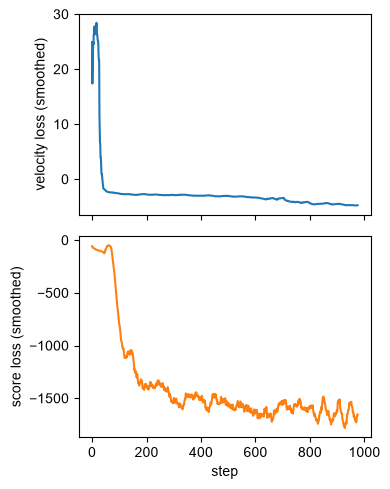

In [11]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(4, 5))
ax[0].plot(smooth(hist_b), "-C0")
ax[0].set_ylabel("velocity loss (smoothed)")
ax[1].plot(smooth(hist_s), "-C1")
ax[1].set_xlabel("step")
ax[1].set_ylabel("score loss (smoothed)")
plt.tight_layout()
plt.show()

### 4. Sampling

Push base samples through the built-in samplers (inherited unchanged from `EESI`):
`sample_ode` integrates the probability-flow ODE `dx/dt = b(t, x)`; `sample_sde` integrates
the reverse-time SDE using both `b` and `s`. There is no closed form to compare against
here, so we validate on two physical observables of generated vs. reference configurations:
the pair-distance distribution *g(r)*, and the Lennard-Jones energy.

In [17]:
torch.manual_seed(4)
n_gen = 500
x0 = sample_prior(n_gen, 55, device=device)

# ODE sampling
gen_ode = chunked(lambda c: model.sample(c, n_steps=100), x0)

# eps is a diffusion coef that does not (in principle) change the sampling
#gen_sde = chunked(lambda c: model.sample(c, n_steps=100, eps=0.1), x0) 


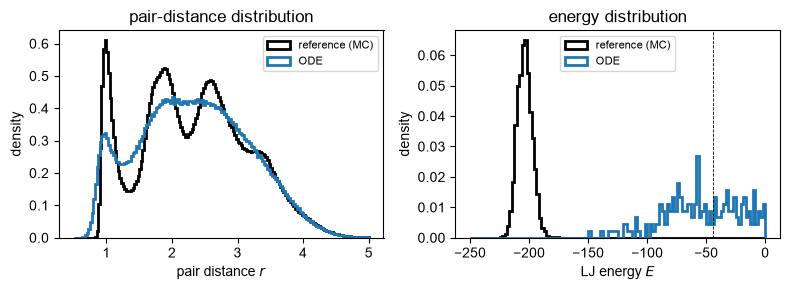

reference (MC)    <E> = -203.848   std(E) =  6.179   min = -224.235
ODE               <E> =  +36.013   std(E) = 119.858   min = -148.580


In [16]:
series = [(x1,             "reference (MC)", "k"),
          #(gen_ckpt,       "checkpoint RK4", "0.55"),
          (gen_ode,        "ODE",            "C0"),
          #(gen_sde,        "SDE",            "C3")]
            ]
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
rbins = np.linspace(0.5, 5.0, 181)
for x, lbl, c in series:
    ax[0].hist(pair_distances(x), bins=rbins, density=True, histtype="step", lw=2,
               label=lbl, color=c)
ax[0].set_xlabel(r"pair distance $r$"); ax[0].set_ylabel("density")
ax[0].set_title("pair-distance distribution"); ax[0].legend(fontsize=8)

ebins = np.linspace(-250, 0, 121)
for x, lbl, c in series:
    ax[1].hist(energy(x), bins=ebins, density=True, histtype="step", lw=2, label=lbl, color=c)
ax[1].axvline(-44.327, c="k", lw=0.6, ls="--")
ax[1].set_xlabel("LJ energy $E$"); ax[1].set_ylabel("density")
ax[1].set_title("energy distribution"); ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for x, lbl, _ in series:
    e = energy(x)
    print(f"{lbl:16s}  <E> = {e.mean():+8.3f}   std(E) = {e.std():6.3f}   min = {e.min():+8.3f}")

### 5. Entropy estimates

The differential-entropy change between base and target, estimated three ways (all inherited
from `EESI`): `entropy_estimate_dot` (mean of $-b\cdot s$), `entropy_estimate_div` (mean of
$\nabla\!\cdot b$, score-free — Hutchinson with **centered** probes, so the trace is taken on
the 36-dim COM-free subspace, not the 39-dim ambient space), and the running ODE path
integral from `sample_ode_entropy_traj`.

Unlike the XY chain there is no closed form to check against, so the test is *mutual*
agreement of the three estimators. They fail in different ways — `dot` compounds score error
onto drift error, `div` is score-free but higher-variance — so agreement is real evidence.
The batched estimators re-couple, hence `batch_size` again.

In [56]:

torch.manual_seed(4)
n_batches = 100
means_dot, means_div = [], []
for _ in range(n_batches):
    idx = torch.randint(0, n_data, (batch_size,), device=device)
    x1_sample = x1[idx]
    x0 = sample_prior(batch_size, device=device)
    x0, x1_sample = equivariant_ot_couple(x0, x1_sample)
    means_dot.append(model.entropy_estimate(x1_sample,x0,method="dot").mean().item())
    means_div.append(model.entropy_estimate(x1_sample,x0,method="div").mean().item())

print(f"entropy estimate (b·s)   : {np.mean(means_dot):+.3f} ± {1.96*np.std(means_dot)/np.sqrt(n_batches):.3f}")
print(f"entropy estimate (div b) : {np.mean(means_div):+.3f} ± {1.96*np.std(means_div)/np.sqrt(n_batches):.3f}")
print(f"entropy estimate (TI)    : {-34.1654956596782:+.3f} ± {0.018956693545144593:.3f}")

entropy estimate (b·s)   : -32.966 ± 0.331
entropy estimate (div b) : -34.767 ± 0.281
entropy estimate (TI)    : -34.165 ± 0.019


In [57]:
torch.manual_seed(5)
x0 = sample_prior(1_000, device=device)
traj, ent_traj, ts = model.sample(x0, n_steps=50, return_traj=True, entropy='div')
ts_c, ent_c_div = ts.cpu().numpy(), ent_traj.cpu().numpy()

In [63]:
# Running entropy change along many ODE paths.
torch.manual_seed(5)
x0 = sample_prior(1_000, device=device)
traj, ent_traj, ts = model.sample(x0, n_steps=50, return_traj=True, entropy='dot')
ts_c, ent_c_dot = ts.cpu().numpy(), ent_traj.cpu().numpy()
print(f"entropy estimate (divergence)     : {ent_c_div[-1].mean():+.3f} ± {1.96*ent_c_div[-1].std()/np.sqrt(1_000):.3f}")
print(f"entropy estimate (inner product)  : {ent_c_dot[-1].mean():+.3f} ± {1.96*ent_c_dot[-1].std()/np.sqrt(1_000):.3f}")


entropy estimate (divergence)     : -34.278 ± 0.227
entropy estimate (inner product)  : -32.520 ± 0.430


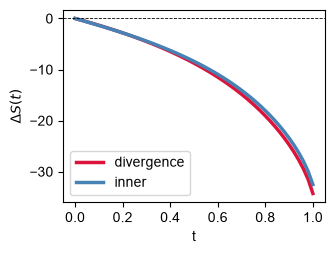

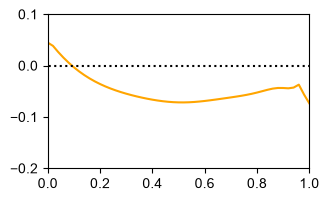

In [64]:
fig, ax = plt.subplots(figsize=(3.375, 2.5))
#ax.plot(ts_c, ent_c[:, :500], c="steelblue", lw=0.4, alpha=0.1)
ax.plot(ts_c, ent_c_div.mean(axis=1), c="crimson", lw=2.5, label="divergence")
ax.plot(ts_c, ent_c_dot.mean(axis=1), c="steelblue", lw=2.5, label="inner")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.legend()
plt.show()

div_mean = ent_c_div.mean(axis=1)
dot_mean = ent_c_dot.mean(axis=1)

dsdt_div = np.gradient(div_mean)
dsdt_dot = np.gradient(dot_mean)
err = (dsdt_dot - dsdt_div)/dsdt_div

fig, ax = plt.subplots(figsize=(3.375, 2))
plt.plot(ts_c,err,'-',color='orange')
plt.axhline(0,-1,1,color='k',linestyle=':',lw=1.5)
plt.ylim(-0.2,0.1)
plt.xlim(0,1)
plt.show()
